# Example session: loading and analyzing one imaging session

This notebook walks through one preprocessed session, **JG6 / 260929 / session_1**:
- V1, layers 1–3
- 3 imaging planes, 2 channels (G = GCaMP, R = red label)
- a linear track with gratings and no reward. The track has no landmarks, so cells aren't expected to have reliable position tuning. The position analyses below are templates for mazes where position matters.

It shows how to load the `AnnData` object that `preprocess.py` produces, what is stored where, and a few analyses that use the package's helpers.

To run it you need:
- the `mouse_imaging` kernel (see the README)
- read access to `/data/green_lab/shared/data/derived/twophoton/`
- a session that has been preprocessed: `sbatch mouse_imaging/preprocess.slurm <mouse> <date> [session]`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mouse_imaging import sess, an, pl, options

plt.rcParams['figure.dpi'] = 80

## 1. Load the session

`sess.load_as_anndata` finds `adata.h5ad` from the mouse, date and session, and reads it.

In [2]:
adata = sess.load_as_anndata('JG6', '260929', 'session_1')
adata

AnnData object with n_obs × n_vars = 9250 × 1932
    obs: 't', 'dt', 'world_id', 'dx', 'dy', 'dh', 'x', 'y', 'h_int', 'inITI', 'reward', 'lick', 'user0', 'user1', 'user2', 'trial', 'h'
    var: 'G', 'R', 'isnotclipped', 'isnotnearedge', 'iscell', 'iscell_prob', 'redcell', 'redcell_prob', 'plane', 'y', 'x'
    uns: 'metadata', 'ops', 'path', 'qc', 'triggers', 'vr'
    layers: 'dF', 'dcnv', 'dcnv_0.25sigma', 'dcnv_0.25sigma_norm', 'dcnv_norm'

## 2. What's inside

| Where | Shape | Contents |
|---|---|---|
| `adata.X` | volumes × cells | Deconvolved activity (suite2p `spks`). Same as `layers['dcnv']`. |
| `adata.layers['dF']` | volumes × cells | dF/F |
| `adata.obs` | one row per imaging volume | Time `t` (s, on the sync clock), ViRMEn variables resampled to each volume: position `y`, velocity `dy`, `trial`, ... |
| `adata.var` | one row per cell | `plane`, pixel position `x`/`y`, channel brightness `G`/`R`, suite2p `iscell` and `redcell` with their probabilities |
| `adata.uns` | — | `metadata` (ScanImage header, `nslices`, `volume_rate`, `maze`, ...), `ops`, file `path`s, raw-rate `vr` table, sync `triggers` |

Cells are named `plane{p}_source{i}`, where `i` is the ROI's index in that plane's suite2p `stat.npy`.

In [3]:
adata.obs.head()

,t,dt,world_id,dx,dy,dh,x,y,h_int,inITI,reward,lick,user0,user1,user2,trial,h
0,48.1715,NaN,1,-0.0,68.440598,-0.0,0.0,25.032341,0.0,0,0,0,-0.499566,-0.002535,0.006606,1,-0.0
1,48.3045,0.1330,1,-0.0,64.572395,-0.0,0.0,34.268494,0.0,0,0,0,-0.471331,-0.036875,-0.020727,1,-0.0
2,48.4380,0.1335,1,-0.0,38.702021,-0.0,0.0,41.722015,0.0,0,0,0,-0.282497,-0.045763,-0.014493,1,-0.0
3,48.5710,0.1330,1,-0.0,19.766883,0.0,0.0,45.675761,0.0,0,0,0,-0.144284,0.011738,-0.006352,1,-0.0
4,48.7045,0.1335,1,-0.0,51.806618,0.0,0.0,49.824665,0.0,0,0,0,-0.378150,0.038504,-0.005888,1,-0.0


In [4]:
adata.var.head()

,G,R,isnotclipped,isnotnearedge,iscell,iscell_prob,redcell,redcell_prob,plane,y,x
plane0_source1,393.813591,14.320574,True,True,True,0.957399,False,0.0,0,243,101
plane0_source2,211.445506,15.328850,True,True,True,0.639245,False,0.0,0,227,123
plane0_source3,104.042001,6.657603,True,True,True,0.727891,False,0.0,0,237,431
plane0_source4,287.967953,12.261926,True,True,True,0.644722,False,0.0,0,223,467
plane0_source5,139.155350,1.578474,True,True,True,0.753696,False,0.0,0,169,463


In [5]:
md = adata.uns['metadata']
print(f"{md['mouse']} {md['date']} {md['session']}: region {md['region']}, maze {md['maze']}")
print(f"{md['nslices']} planes at {md['volume_rate']:.2f} volumes/s, {adata.n_obs} volumes ({adata.obs['t'].iloc[-1] - adata.obs['t'].iloc[0]:.0f} s), {adata.n_vars} cells")
print('Cells per plane:', adata.var['plane'].value_counts().sort_index().to_dict())

JG6 260929 session_1: region V1, maze linearTrack_grating_noReward
3 planes at 7.50 volumes/s, 9250 volumes (1233 s), 1932 cells
Cells per plane: {0: 397, 1: 672, 2: 863}


## 3. Activity layers

Besides `X` (deconvolved activity, also in the `dcnv` layer) and `dF` (dF/F), the AnnData has smoothed and normalized copies of the deconvolved activity, added by `sess.preprocess_activity` during preprocessing. Many analysis functions expect these layers:
- `dcnv_0.25sigma`: Gaussian-smoothed with σ = 0.25 s
- `dcnv_norm` and `dcnv_0.25sigma_norm`: each cell divided by its 99th percentile

In [6]:
list(adata.layers.keys())

['dF', 'dcnv', 'dcnv_0.25sigma', 'dcnv_0.25sigma_norm', 'dcnv_norm']

## 4. Field of view

Mean images come from suite2p's `ops.npy`. Here they are shown as red/green overlays, followed by the footprints of all selected cells in each plane.

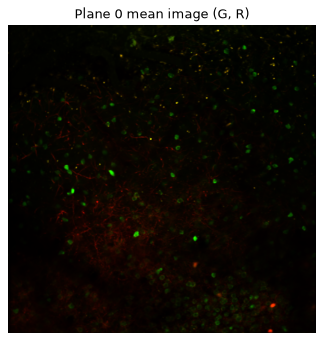

In [7]:
plt.figure(figsize=(5, 5))
pl.plot_top_slice(adata)
plt.title('Plane 0 mean image (G, R)')
plt.axis('off');

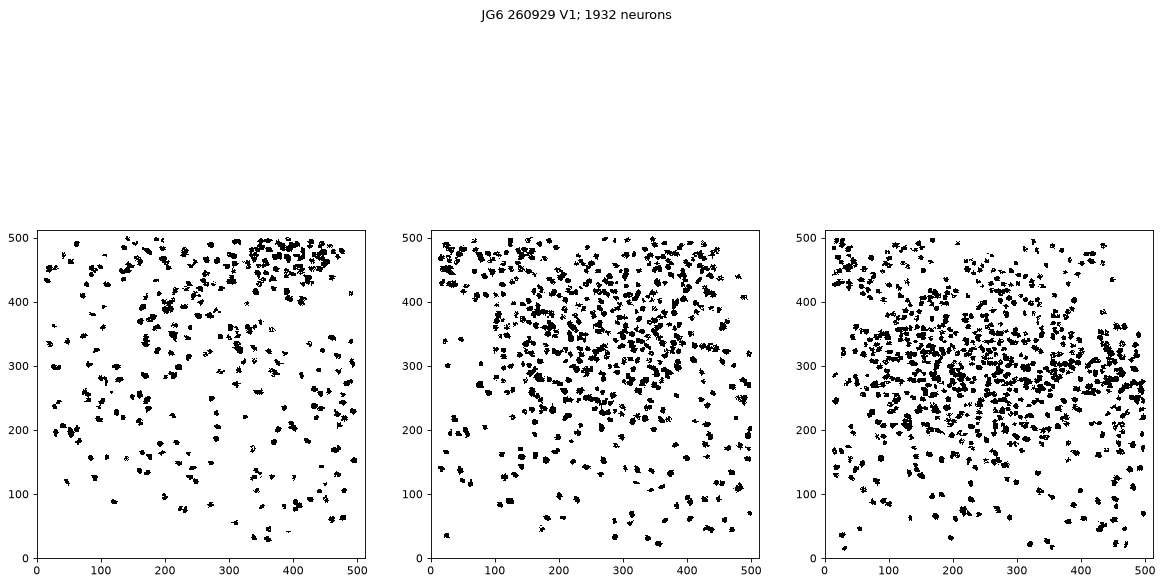

In [8]:
pl.plot_cell_footprints(adata, cmap='Greys')

## 5. Behavior

On the linear track, `y` runs from 0 to 400 on each lap, and `dy` is forward velocity (ViRMEn units per iteration). Before the analyses below, we add two columns to `obs`: whether the mouse is running, and whether a lap is odd or even. The odd/even split is used to cross-validate.

47 laps, running 48% of the time


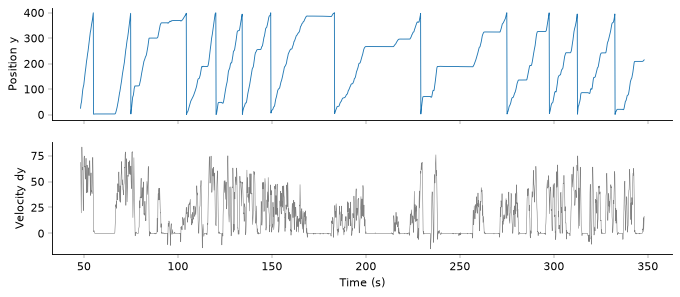

In [9]:
adata.obs['running'] = adata.obs['dy'] > 5
adata.obs['odd_lap'] = adata.obs['trial'] % 2 == 1

fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
window = adata.obs['t'] < adata.obs['t'].iloc[0] + 300
axes[0].plot(adata.obs['t'][window], adata.obs['y'][window], lw=0.8)
axes[0].set_ylabel('Position y')
axes[1].plot(adata.obs['t'][window], adata.obs['dy'][window], lw=0.5, color='grey')
axes[1].set_ylabel('Velocity dy')
axes[1].set_xlabel('Time (s)')
for ax in axes: pl.format_plot(ax)
print(f"{adata.obs['trial'].nunique()} laps, running {adata.obs['running'].mean():.0%} of the time")

## 6. Selecting data with `obs_key` and `var_key`

Most analysis functions take `obs_key` (which volumes) and `var_key` (which cells) as dicts of column → value. A string value starting with `<`, `>`, `=` or `!` is a comparison. `functions.fetch_index` converts a key into a boolean index.

In [10]:
from mouse_imaging import functions as fc
running_idx = fc.fetch_index(adata.obs, {'running': True})
plane0_idx = fc.fetch_index(adata.var, {'plane': 0, 'iscell_prob': '>0.8'})
print(running_idx.sum(), 'running volumes;', plane0_idx.sum(), 'plane-0 cells with iscell_prob > 0.8')

4411 running volumes; 272 plane-0 cells with iscell_prob > 0.8


## 7. Activity along the track

`an.binX1` averages each cell's activity in position bins. This track has no landmarks, so we don't expect reliable position tuning here. The analysis shows the method for sessions in mazes that do have landmarks. To test whether position tuning is reliable, we:
1. order cells by their peak position on **odd** laps
2. plot their activity on **even** laps in that order

If position tuning is reliable, the even-lap plot also shows a diagonal.

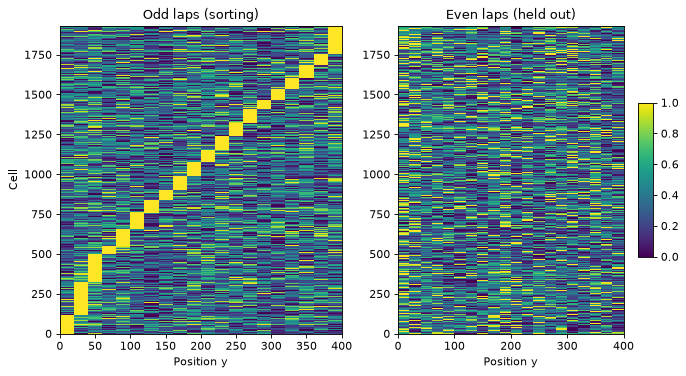

In [11]:
bins = np.arange(0, 401, 20)

def norm_rows(df):
    return df.sub(df.min(axis=1), axis=0).div(df.max(axis=1) - df.min(axis=1), axis=0)

tuning_odd = an.binX1(adata, obs='y', bins=bins, obs_key={'running': True, 'odd_lap': True})
tuning_even = an.binX1(adata, obs='y', bins=bins, obs_key={'running': True, 'odd_lap': False})
order = norm_rows(tuning_odd).values.argmax(axis=1).argsort()

fig = plt.figure(figsize=(10, 5))
for i, (name, df) in enumerate([('Odd laps (sorting)', tuning_odd), ('Even laps (held out)', tuning_even)]):
    plt.subplot(1, 2, i + 1)
    pl.pcolormesh(norm_rows(df).values[order], xticks=bins, cmap='viridis', cbar=(i == 1))
    plt.title(name)
    plt.xlabel('Position y')
    plt.ylabel('Cell' if i == 0 else '')

To summarize reliability, correlate each cell's odd-lap and even-lap tuning curves. For comparison, a control circularly shifts the even-lap curve by half the track, which breaks any real position relationship.

Median reliability 0.07 (control 0.08); 7% of cells > 0.5 (control 7%)


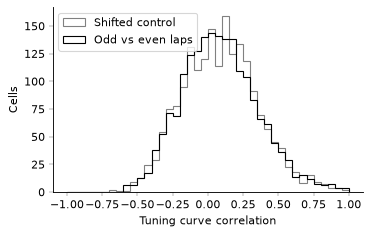

In [12]:
def rowwise_corr(a, b):
    a = a - a.mean(axis=1, keepdims=True)
    b = b - b.mean(axis=1, keepdims=True)
    return (a * b).sum(axis=1) / np.sqrt((a**2).sum(axis=1) * (b**2).sum(axis=1))

reliability = rowwise_corr(tuning_odd.values, tuning_even.values)
control = rowwise_corr(tuning_odd.values, np.roll(tuning_even.values, len(bins) // 2, axis=1))
adata.var['position_reliability'] = reliability

plt.figure(figsize=(5, 3))
hist_bins = np.linspace(-1, 1, 41)
plt.hist(control, bins=hist_bins, histtype='step', color='grey', label='Shifted control')
plt.hist(reliability, bins=hist_bins, histtype='step', color='k', label='Odd vs even laps')
plt.xlabel('Tuning curve correlation')
plt.ylabel('Cells')
plt.legend()
pl.format_plot(plt.gca())
print(f'Median reliability {np.nanmedian(reliability):.2f} (control {np.nanmedian(control):.2f}); '
      f'{np.nanmean(reliability > 0.5):.0%} of cells > 0.5 (control {np.nanmean(control > 0.5):.0%})')

As expected for a track without landmarks, odd/even reliability here is about the same as the shifted control. In a maze with landmarks, reliably tuned cells would show up as a shift of the black histogram to the right of the grey one. `an.cell_tuning` returns each cell's preferred position, with optional thresholds such as `min_delta` and `min_pvalue`, so you can then keep only tuned cells.

In [13]:
adata.var['y_peak'] = an.cell_tuning(adata, 'y', obs_key={'running': True}, bins=bins, layer='dcnv_norm')
adata.var['y_peak'].describe()

count    1932.000000
mean      177.111801
std       125.467296
min        10.000000
25%        50.000000
50%       170.000000
75%       290.000000
max       390.000000
Name: y_peak, dtype: float64

## 8. Activity triggered on lap starts

`an.trigger_inds` finds events in an `obs` column, here each increase in `trial`, and returns indices for a time window around each event. `an.compute_Xtrig` uses them to cut out activity, with axes (cells, events, time). `an.compute_VRtrig` does the same for a behavior column.

46 lap starts, window -2.9 to 5.7 s


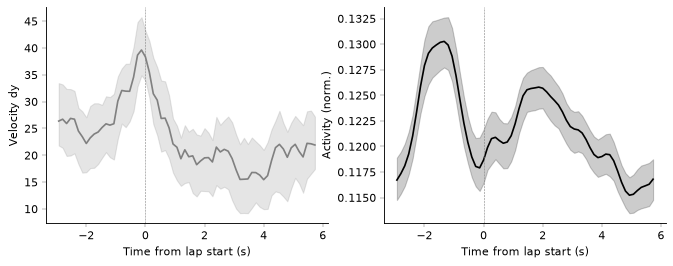

In [14]:
trig = an.trigger_inds(adata.obs, trigger_name='trial', t_range=(-3, 6), safe=True)
Xtrig = an.compute_Xtrig(adata, trig=trig, layer='dcnv_0.25sigma_norm')    # (cells, laps, time)
speed_trig = an.compute_VRtrig(adata.obs, col='dy', trig=trig)              # (laps, time)
print(f"{trig['ntrials']} lap starts, window {trig['t'][0]:.1f} to {trig['t'][-1]:.1f} s")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
plt.sca(axes[0])
pl.lineplot(speed_trig, xticks=trig['t'], color='grey')
plt.ylabel('Velocity dy'); plt.xlabel('Time from lap start (s)')
plt.sca(axes[1])
pl.lineplot(np.nanmean(Xtrig, axis=1), xticks=trig['t'], color='k')   # mean over laps, then mean +/- CI over cells
plt.ylabel('Activity (norm.)'); plt.xlabel('Time from lap start (s)')
for ax in axes:
    ax.axvline(0, ls='--', lw=0.5, color='grey')
    pl.format_plot(ax)

## 9. Running modulation

Correlate each cell's smoothed activity with velocity, then compare across planes.

plane
0   -0.006058
1   -0.040783
2   -0.056498
Name: speed_corr, dtype: float64

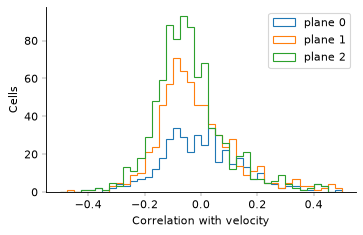

In [15]:
X = adata.layers['dcnv_0.25sigma_norm']
v = adata.obs['dy'].to_numpy()
Xz = (X - X.mean(axis=0)) / X.std(axis=0)
vz = (v - v.mean()) / v.std()
adata.var['speed_corr'] = Xz.T @ vz / len(vz)

plt.figure(figsize=(5, 3))
for plane, var_plane in adata.var.groupby('plane'):
    plt.hist(var_plane['speed_corr'], bins=np.linspace(-0.5, 0.5, 41), histtype='step', label=f'plane {plane}')
plt.xlabel('Correlation with velocity'); plt.ylabel('Cells'); plt.legend()
pl.format_plot(plt.gca())
adata.var.groupby('plane')['speed_corr'].median()

## 10. Red channel

`R` is each cell's red brightness on the channel-2 mean image, minus a 2-pixel ring around the cell, so it's background-subtracted. `redcell_prob` is suite2p's red-cell probability. With the current `chan2_threshold` (0.25), suite2p's binary `redcell` flag is True for almost every cell, so use `R` or `redcell_prob` with your own cutoff.

,count,mean,50%
R_high,,,
False,1738.0,-0.019830,-0.044413
True,194.0,-0.026324,-0.034824


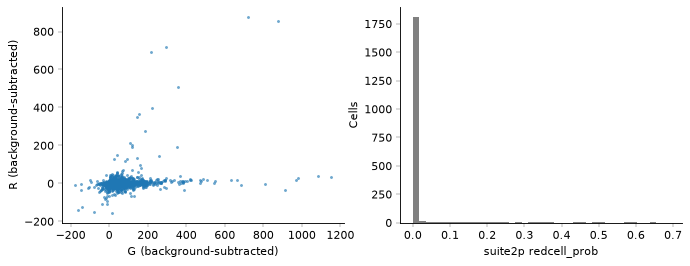

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].scatter(adata.var['G'], adata.var['R'], s=3, alpha=0.5)
axes[0].set_xlabel('G (background-subtracted)'); axes[0].set_ylabel('R (background-subtracted)')
axes[1].hist(adata.var['redcell_prob'], bins=40, color='grey')
axes[1].set_xlabel('suite2p redcell_prob'); axes[1].set_ylabel('Cells')
for ax in axes: pl.format_plot(ax)

# Example: label the top 10% of cells by R and compare their running modulation
adata.var['R_high'] = adata.var['R'] > adata.var['R'].quantile(0.9)
adata.var.groupby('R_high')['speed_corr'].describe()[['count', 'mean', '50%']]

## 11. Looking at individual cells

`pl.imshow_cell` crops a cell from each channel's mean image and outlines its suite2p footprint. Below is the cell most correlated with running, with its activity alongside.

plane1_source236 {'plane': 1, 'x': 467, 'y': 133, 'G': 66.88222175703146, 'R': 2.285837091537079, 'speed_corr': 0.6525615276542738}


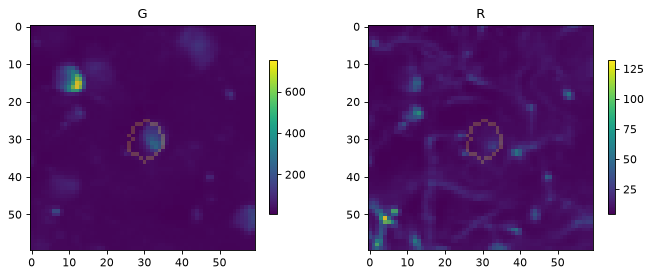

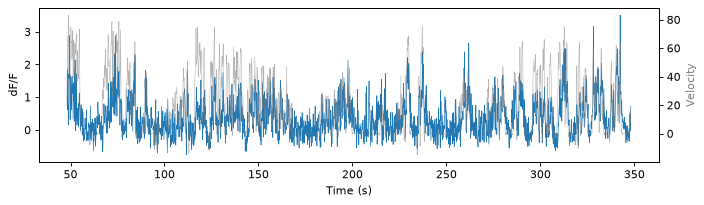

In [17]:
cell = adata.var['speed_corr'].idxmax()
print(cell, adata.var.loc[cell, ['plane', 'x', 'y', 'G', 'R', 'speed_corr']].to_dict())
pl.imshow_cell(adata, cell, channels=['G', 'R'])

fig, ax = plt.subplots(figsize=(10, 2.5))
window = adata.obs['t'] < adata.obs['t'].iloc[0] + 300
ax.plot(adata.obs['t'][window], adata[:, cell].layers['dF'][window.to_numpy(), 0], lw=0.6, label='dF/F')
ax2 = ax.twinx()
ax2.plot(adata.obs['t'][window], adata.obs['dy'][window], lw=0.5, color='grey', alpha=0.6)
ax.set_xlabel('Time (s)'); ax.set_ylabel('dF/F'); ax2.set_ylabel('Velocity', color='grey');

## 12. Next steps

- **Several sessions:** `sess.load_imaging_sessions('JG6', ['260929', '261006'])` returns a list of AnnData objects. Many `pl.*` functions accept a list.
- **Saving results:** columns added above, such as `speed_corr` and `position_reliability`, exist only in memory. To keep them, write to your own file, e.g. `adata.write('my_analysis.h5ad')`, rather than overwriting the pipeline's `adata.h5ad`.
- **Maze variables:** derived behavior variables (goal direction, trial outcome, ...) come from an `env` module such as `tmaze`. A linear-track module hasn't been written yet.